In [1]:
import gc
gc.collect()

import torch
torch.cuda.empty_cache()  # Safe to call even on CPU


In [2]:
import pandas as pd

df = pd.read_csv('return_predictability_data.csv')
df.shape

/var/folders/mn/p97zg4190kl_grdrb5c91h7m0000gn/T/ipykernel_25861/1032643601.py:3: DtypeWarning: Columns (98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('return_predictability_data.csv')


(4089924, 107)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4089924 entries, 0 to 4089923
Columns: 107 entries, permno to macro_svar
dtypes: float64(102), int64(1), object(4)
memory usage: 3.3+ GB


In [4]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

realestate    3013381
rd_sale       2657364
rd_mve        2631975
stdcf         2489634
stdacc        2489634
               ...   
retvol           3449
mvel1            2983
baspread          634
maxret            554
indmom             24
Length: 94, dtype: int64

In [5]:
# df.describe().T  # Transpose for readability
# df.skew(), df.kurtosis()

In [6]:
df.head()

,permno,DATE,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,...,name,RET,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar
0,10006,1957-01-31,82249.000,1.122846,1.260784,0.047180,9.569953,0.025742,0.046433,0.044843,...,A C F INDUSTRIES INC,0.064378,3.248434,2.574677,0.567243,0.027992,0.0311,0.0035,0.0072,0.000902
1,10014,1957-01-31,3903.375,0.426734,0.182102,-0.275641,6.237836,0.072103,0.046433,-0.086957,...,ALASKA JUNEAU GOLD MNG CO,0.095238,3.248434,2.574677,0.567243,0.027992,0.0311,0.0035,0.0072,0.000902
2,10022,1957-01-31,9273.250,1.066449,1.137313,-0.025490,7.008844,0.027648,0.046433,-0.060377,...,AMERICAN SAFETY RAZOR CORP,0.102041,3.248434,2.574677,0.567243,0.027992,0.0311,0.0035,0.0072,0.000902
3,10030,1957-01-31,54465.875,0.926038,0.857547,0.018171,9.825337,0.021700,0.046433,0.044633,...,AMERICAN BRAKE SHOE CO,-0.047091,3.248434,2.574677,0.567243,0.027992,0.0311,0.0035,0.0072,0.000902
4,10057,1957-01-31,40250.000,1.247748,1.556875,0.025785,7.901007,0.025506,0.046433,0.086667,...,NATIONAL ACME CO,-0.090062,3.248434,2.574677,0.567243,0.027992,0.0311,0.0035,0.0072,0.000902


In [7]:
df['RET'].value_counts()

RET
 0.0          166895
-0.125         10055
-0.111111       9698
-0.166667       9602
-0.1            9465
               ...  
 0.198688          1
 0.170969          1
 -0.128649         1
 0.15947           1
-0.087643          1
Name: count, Length: 526825, dtype: int64

In [8]:
df['RET'] = pd.to_numeric(df['RET'], errors='coerce')

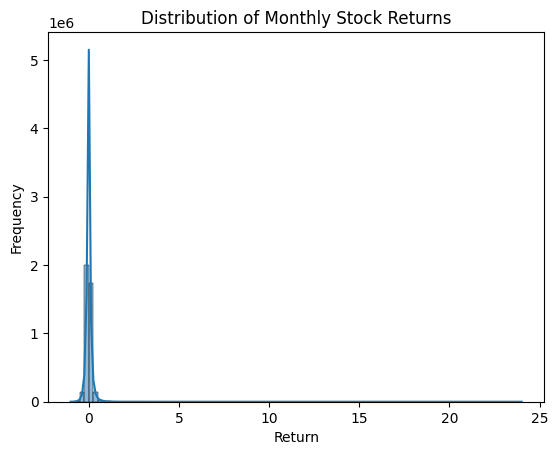

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert RET to numeric, but keep original dataframe
df['RET_clean'] = pd.to_numeric(df['RET'], errors='coerce')

# Plot only the valid (non-NaN) returns
sns.histplot(df['RET_clean'].dropna(), bins=100, kde=True)
plt.title("Distribution of Monthly Stock Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

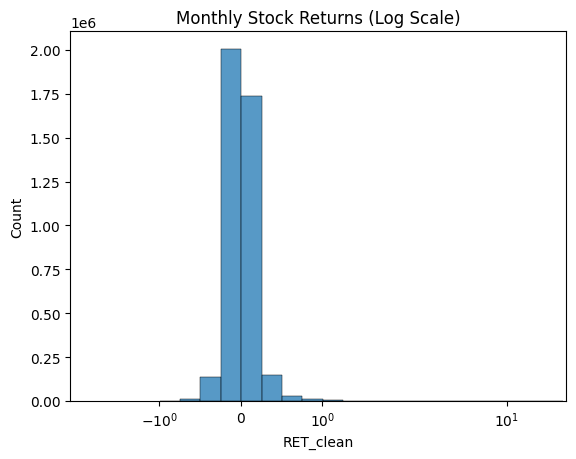

In [10]:
import numpy as np

sns.histplot(df['RET_clean'].dropna(), bins=100)
plt.xscale('symlog')  # Symmetric log scale for both sides of zero
plt.title("Monthly Stock Returns (Log Scale)")
plt.show()


In [11]:
correlations = df.corr(numeric_only=True)['RET_clean'].sort_values()
print("Top Negative Correlations:\n", correlations.head(10))
print("\nTop Positive Correlations:\n", correlations.tail(10))

Top Negative Correlations:
 macro_svar   -0.113729
mom36m       -0.019619
dolvol       -0.019271
invest       -0.017468
hire         -0.017340
chcsho       -0.016459
grltnoa      -0.016211
egr          -0.015936
lgr          -0.015840
sgr          -0.015478
Name: RET_clean, dtype: float64

Top Positive Correlations:
 retvol       0.018068
ill          0.021454
macro_ep     0.022427
macro_dfy    0.022735
sp           0.024985
baspread     0.025430
agr          0.026220
rd_mve       0.029766
RET          1.000000
RET_clean    1.000000
Name: RET_clean, dtype: float64


<Axes: title={'center': 'Average Monthly Return Over Time'}, xlabel='DATE'>

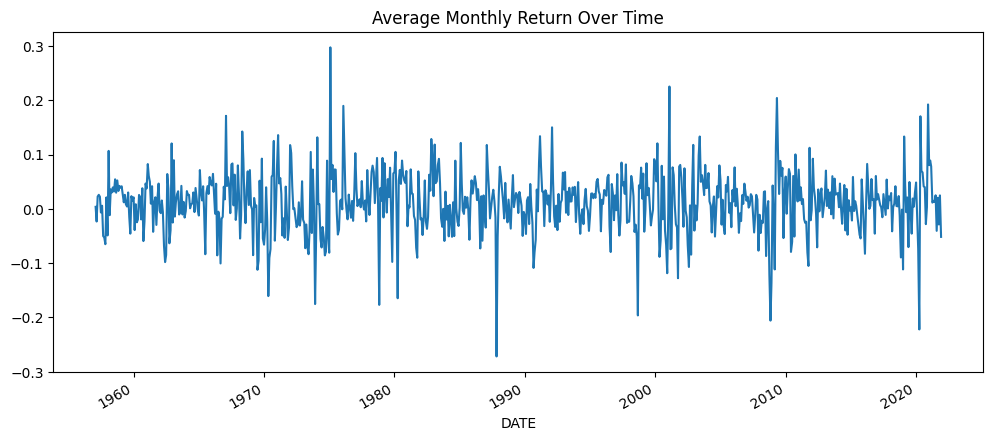

In [12]:
df['DATE'] = pd.to_datetime(df['DATE'])
monthly_avg = df.groupby('DATE')['RET_clean'].mean()

monthly_avg.plot(figsize=(12,5), title="Average Monthly Return Over Time")


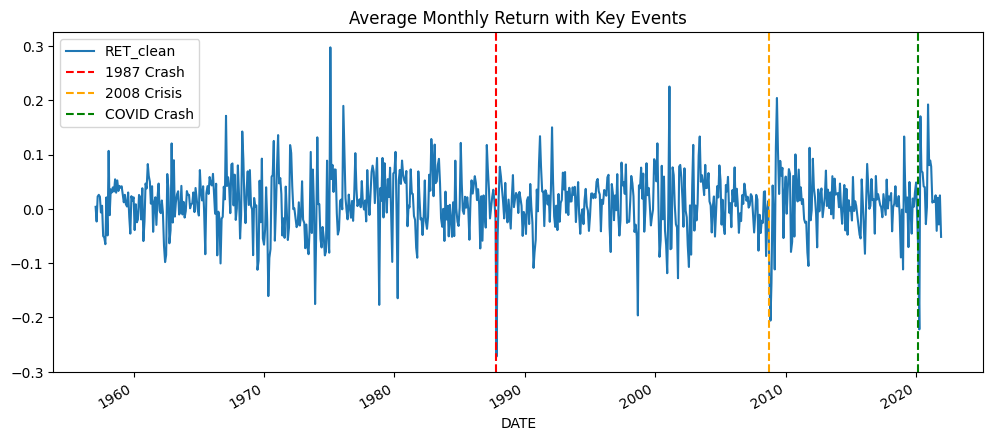

In [13]:
import matplotlib.pyplot as plt
monthly_avg.plot(figsize=(12,5))
plt.axvline(pd.to_datetime('1987-10-01'), color='red', linestyle='--', label='1987 Crash')
plt.axvline(pd.to_datetime('2008-10-01'), color='orange', linestyle='--', label='2008 Crisis')
plt.axvline(pd.to_datetime('2020-03-01'), color='green', linestyle='--', label='COVID Crash')
plt.legend()
plt.title("Average Monthly Return with Key Events")
plt.show()


Text(0.5, 1.0, '12-Month Rolling Avg Return')

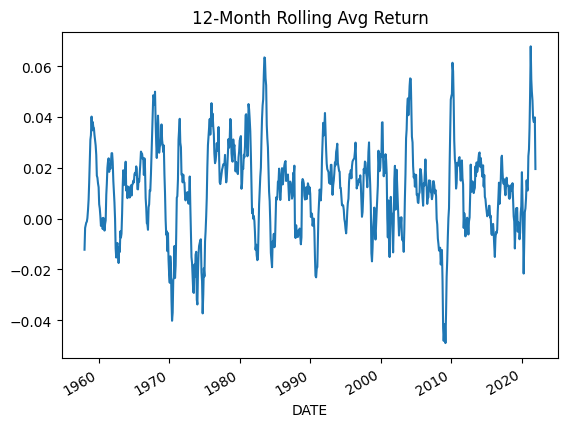

In [14]:
monthly_avg.rolling(window=12).mean().plot()
plt.title("12-Month Rolling Avg Return")


In [15]:
df['RET_decile'] = pd.qcut(df['RET_clean'], 10, labels=False)  # 0 = worst returns, 9 = best

In [16]:
selected_features = ['mom36m', 'invest', 'hire', 'retvol', 'ill', 'rd_mve']

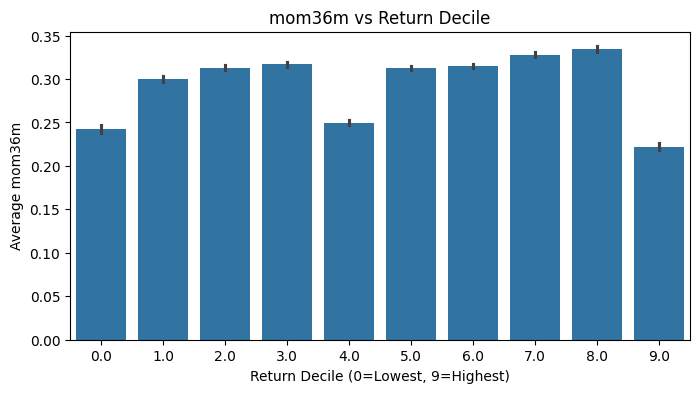

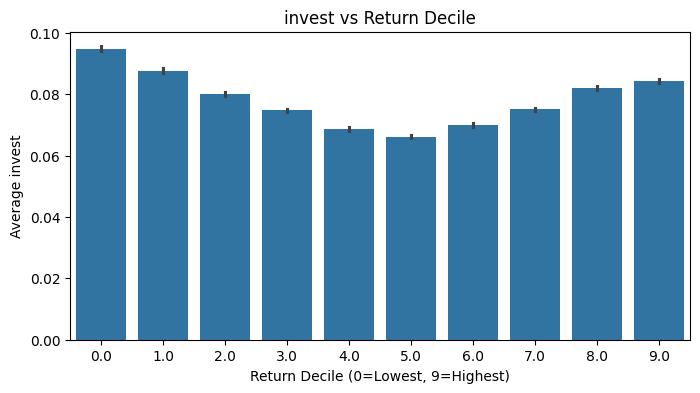

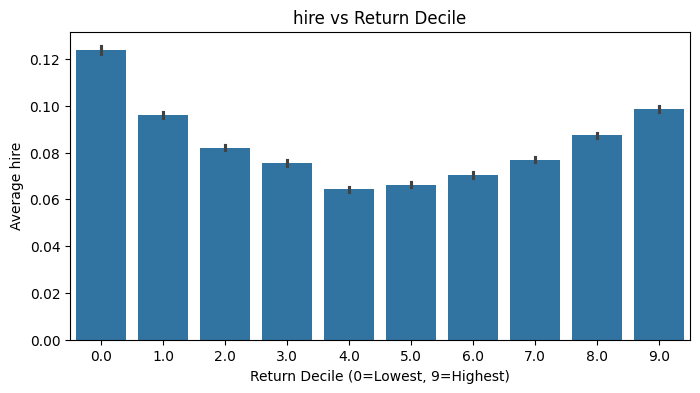

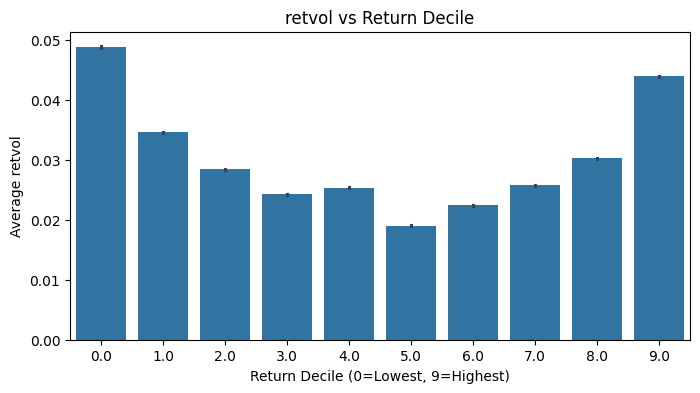

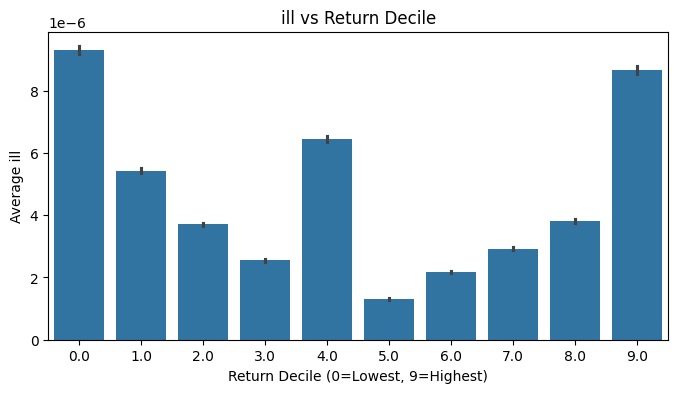

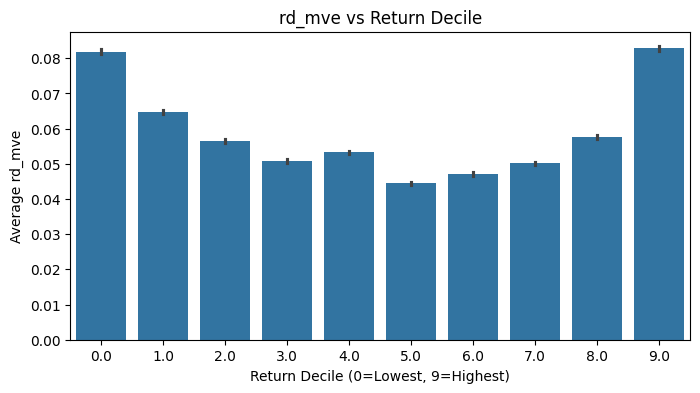

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in selected_features:
    plt.figure(figsize=(8,4))
    sns.barplot(x='RET_decile', y=feature, data=df)
    plt.title(f'{feature} vs Return Decile')
    plt.xlabel('Return Decile (0=Lowest, 9=Highest)')
    plt.ylabel(f'Average {feature}')
    plt.show()

In [18]:
# Exclude non-feature columns
non_features = ['permno', 'DATE', 'name', 'RET', 'RET_clean', 'RET_decile']

# Find numeric feature columns
feature_cols = [col for col in df.columns if col not in non_features]


In [19]:
# Convert all feature columns to numeric (non-numeric becomes NaN)
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [20]:
# Fill missing values with median
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())


In [21]:
print("Missing values left:", df[feature_cols].isnull().sum().sum())

Missing values left: 0


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [23]:
from sklearn.model_selection import train_test_split

# Calculate quantiles for splits
train_split = df['DATE'].quantile(0.6)
val_split = df['DATE'].quantile(0.8)

# Split the data
train_df = df[df['DATE'] <= train_split]
val_df = df[(df['DATE'] > train_split) & (df['DATE'] <= val_split)]
test_df = df[df['DATE'] > val_split]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (2456624, 109)
Validation: (818668, 109)
Test: (814632, 109)


In [24]:
X_train = train_df[feature_cols]
y_train = train_df['RET_clean']

X_val = val_df[feature_cols]
y_val = val_df['RET_clean']

X_test = test_df[feature_cols]
y_test = test_df['RET_clean']

In [25]:
# For Training Already Done:
X_train_clean = X_train[y_train.notnull()]
y_train_clean = y_train[y_train.notnull()]

# For Validation
X_val_clean = X_val[X_val.notnull().all(axis=1)]
y_val_clean = y_val[X_val.notnull().all(axis=1)]

# For Test
X_test_clean = X_test[X_test.notnull().all(axis=1)]
y_test_clean = y_test[X_test.notnull().all(axis=1)]


In [ ]:
# Mask for Validation
val_mask = X_val.notnull().all(axis=1) & y_val.notnull()
X_val_clean = X_val[val_mask]
y_val_clean = y_val[val_mask]

# Mask for Test
test_mask = X_test.notnull().all(axis=1) & y_test.notnull()
X_test_clean = X_test[test_mask]
y_test_clean = y_test[test_mask]


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
# lr.fit(X_train, y_train)
lr.fit(X_train_clean, y_train_clean)




LinearRegression()

In [50]:
print("Validation R2:", r2_score(y_val_clean, lr.predict(X_val_clean)))
print("Test R2:", r2_score(y_test_clean, lr.predict(X_test_clean)))
print("Test MSE:", mean_squared_error(y_test_clean, lr.predict(X_test_clean)))

Validation R2: -0.038814854302130275
Test R2: -0.13386513508938624
Test MSE: 0.03148831159495587


In [51]:
from sklearn.linear_model import Lasso

ls = Lasso()
ls.fit(X_train_clean, y_train_clean)

Lasso()

In [52]:
print("Validation R2:", r2_score(y_val_clean, ls.predict(X_val_clean)))
print("Test R2:", r2_score(y_test_clean, ls.predict(X_test_clean)))
print("Test MSE:", mean_squared_error(y_test_clean, ls.predict(X_test_clean)))

Validation R2: -0.000919030032979995
Test R2: -0.00014238884476336366
Test MSE: 0.02777472752681891


In [53]:
# Add predictions to the clean test dataframe
test_df_clean = test_df.loc[X_test_clean.index].copy()
test_df_clean['LR_pred'] = lr.predict(X_test_clean)
test_df_clean['LS_pred'] = ls.predict(X_test_clean)

In [27]:
def compute_portfolio_returns(df, prediction_column):
    # For each month, get top 100 predicted stocks
    monthly_returns = []

    for date, group in df.groupby('DATE'):
        top100 = group.sort_values(by=prediction_column, ascending=False).head(100)
        avg_return = top100['RET_clean'].mean()
        monthly_returns.append(avg_return)

    return pd.Series(monthly_returns, name=f"portfolio_return_{prediction_column}")


In [28]:
def evaluate_model_top100(test_df, pred_column):
    monthly_returns = []

    for date, group in test_df.groupby('DATE'):
        top100 = group.sort_values(by=pred_column, ascending=False).head(100)
        avg_return = top100['RET_clean'].mean()
        monthly_returns.append(avg_return)

    model_series = pd.Series(monthly_returns, name=f"Top100_{pred_column}")

    # Portfolio stats
    mean_ret = model_series.mean()
    volatility = model_series.std()
    sharpe = mean_ret / volatility

    return {
        "avg_return": mean_ret,
        "volatility": volatility,
        "sharpe": sharpe,
        "monthly_returns": model_series
    }


In [54]:
lr_returns = compute_portfolio_returns(test_df_clean, 'LR_pred')
ls_returns = compute_portfolio_returns(test_df_clean, 'LS_pred')

In [54]:
oracle_stats = evaluate_model_top100(test_df_clean, 'LS_pred')

print("📊 Actual Top 100 Portfolio (Lasso)")
print(f"Avg Return: {oracle_stats['avg_return']:.4f}")
print(f"Volatility: {oracle_stats['volatility']:.4f}")
print(f"Sharpe Ratio: {oracle_stats['sharpe']:.4f}")


📊 Actual Top 100 Portfolio (Lasso)
Avg Return: 0.0145
Volatility: 0.0546
Sharpe Ratio: 0.2648


In [55]:
oracle_stats = evaluate_model_top100(test_df_clean, 'LR_pred')

print("📊 Actual Top 100 Portfolio (Linear Regression)")
print(f"Avg Return: {oracle_stats['avg_return']:.4f}")
print(f"Volatility: {oracle_stats['volatility']:.4f}")
print(f"Sharpe Ratio: {oracle_stats['sharpe']:.4f}")

📊 Actual Top 100 Portfolio (Linear Regression)
Avg Return: 0.0072
Volatility: 0.0896
Sharpe Ratio: 0.0809


In [29]:
def evaluate_portfolio(returns):
    mean_ret = returns.mean()
    volatility = returns.std()
    sharpe = mean_ret / volatility
    return mean_ret, volatility, sharpe



In [55]:
lr_stats = evaluate_portfolio(lr_returns)
ls_stats = evaluate_portfolio(ls_returns)

print("📊 Linear Regression Portfolio")
print(f"Avg Return: {lr_stats[0]:.4f} | Volatility: {lr_stats[1]:.4f} | Sharpe: {lr_stats[2]:.4f}")

print("\n📊 Lasso Regression Portfolio")
print(f"Avg Return: {ls_stats[0]:.4f} | Volatility: {ls_stats[1]:.4f} | Sharpe: {ls_stats[2]:.4f}")


📊 Linear Regression Portfolio
Avg Return: 0.0072 | Volatility: 0.0896 | Sharpe: 0.0809

📊 Lasso Regression Portfolio
Avg Return: 0.0145 | Volatility: 0.0546 | Sharpe: 0.2648


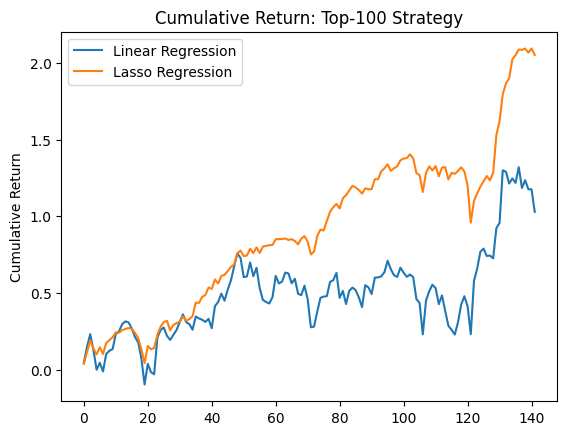

In [43]:
(lr_returns.cumsum()).plot(label='Linear Regression')
(ls_returns.cumsum()).plot(label='Lasso Regression')
plt.legend()
plt.title("Cumulative Return: Top-100 Strategy")
plt.ylabel("Cumulative Return")
plt.show()


In [56]:
# import optuna
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# def objective(trial):
#     alpha = trial.suggest_float('alpha', 1e-5, 1, log=True)
#     fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
#     selection = trial.suggest_categorical('selection', ['cyclic', 'random'])
#     tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)

#     model = Lasso(alpha=alpha, fit_intercept=fit_intercept, selection=selection, tol=tol, max_iter=10000)
#     model.fit(X_train_clean, y_train_clean)
    
#     preds = model.predict(X_val_clean)
#     return r2_score(y_val_clean, preds)


# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# print(study.best_params)
# print(study.best_value)

best_params = {
    'alpha': 0.001682603228232911,
    'fit_intercept': False,
    'max_iter': 10000,
    'selection': 'random',
    'tol': 0.000111182
}


In [57]:
final_lasso = Lasso(
    alpha=best_params['alpha'],
    fit_intercept=best_params['fit_intercept'],
    selection=best_params['selection'],
    tol=best_params['tol'],
    max_iter=10000
)

final_lasso.fit(X_train_clean, y_train_clean)


Lasso(alpha=0.001682603228232911, fit_intercept=False, max_iter=10000,
      selection='random', tol=0.000111182)

In [58]:
print("Validation R2:", r2_score(y_val_clean, final_lasso.predict(X_val_clean)))
print("Test R2:", r2_score(y_test_clean, final_lasso.predict(X_test_clean)))
print("Test MSE:", mean_squared_error(y_test_clean, final_lasso.predict(X_test_clean)))

Validation R2: 0.01903408380033811
Test R2: 0.00939944337717269
Test MSE: 0.0275097434675221


In [59]:
test_df_clean['LS_pred_opt'] = final_lasso.predict(X_test_clean)

In [60]:
ls_opt_returns = compute_portfolio_returns(test_df_clean, 'LS_pred_opt')

In [61]:
ls_opt_stats = evaluate_portfolio(ls_opt_returns)

print("📊 Optimized Lasso Portfolio")
print(f"Avg Return: {ls_opt_stats[0]:.4f} | Volatility: {ls_opt_stats[1]:.4f} | Sharpe: {ls_opt_stats[2]:.4f}")


📊 Optimized Lasso Portfolio
Avg Return: 0.0240 | Volatility: 0.1023 | Sharpe: 0.2349


In [62]:
oracle_stats = evaluate_model_top100(test_df_clean, 'LS_pred_opt')

print("📊 Actual Top 100 Portfolio (Lasso_fine_tuned)")
print(f"Avg Return: {oracle_stats['avg_return']:.4f}")
print(f"Volatility: {oracle_stats['volatility']:.4f}")
print(f"Sharpe Ratio: {oracle_stats['sharpe']:.4f}")

📊 Actual Top 100 Portfolio (Lasso_fine_tuned)
Avg Return: 0.0240
Volatility: 0.1023
Sharpe Ratio: 0.2349


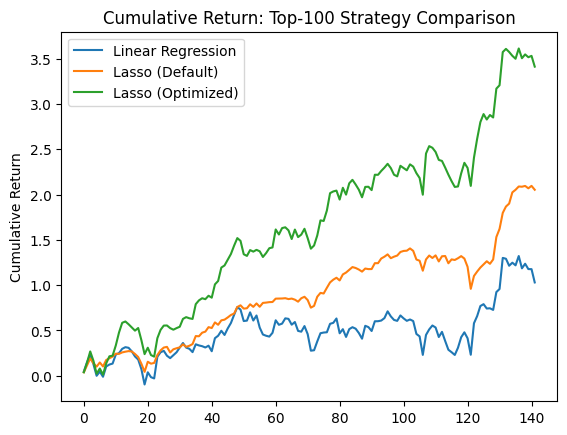

In [61]:
(lr_returns.cumsum()).plot(label='Linear Regression')
(ls_returns.cumsum()).plot(label='Lasso (Default)')
(ls_opt_returns.cumsum()).plot(label='Lasso (Optimized)')
plt.legend()
plt.title("Cumulative Return: Top-100 Strategy Comparison")
plt.ylabel("Cumulative Return")
plt.show()


In [62]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_clean, label=y_train_clean)
dval = xgb.DMatrix(X_val_clean, label=y_val_clean)
dtest = xgb.DMatrix(X_test_clean, label=y_test_clean)

In [50]:
# def objective(trial):
#     params = {
#         'objective': 'reg:squarederror',
#         'tree_method': 'hist',
#         'eval_metric': 'rmse',
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
#         'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True)
#     }

#     booster = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1000,
#         evals=[(dval, 'val')],
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

#     preds = booster.predict(dval)
#     return r2_score(y_val_clean, preds)


In [63]:
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# print("Best Params:", study.best_params)

best_params = {'max_depth': 3, 'eta': 0.012749732361476399, 'subsample': 0.5830926974771112, 'colsample_bytree': 0.90458892084126, 'lambda': 0.0022340521405792998, 'alpha': 0.05708922995103894}


In [64]:
final_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=100
)


[0]	val-rmse:0.18831
[97]	val-rmse:0.18802


In [65]:
print("Validation R2:", r2_score(y_val_clean, final_model.predict(dval)))
print("Test R2:", r2_score(y_test_clean, final_model.predict(dtest)))
print("Test MSE:", mean_squared_error(y_test_clean, final_model.predict(dtest)))

Validation R2: 0.0023960976349747254
Test R2: 0.017621581968074174
Test MSE: 0.027281408320849822


In [66]:
test_df_clean['XGB_pred'] = final_model.predict(dtest)

xgb_returns = compute_portfolio_returns(test_df_clean, 'XGB_pred')

xgb_stats = evaluate_portfolio(xgb_returns)

print("📊 XGBoost Portfolio")
print(f"Avg Return: {xgb_stats[0]:.4f} | Volatility: {xgb_stats[1]:.4f} | Sharpe: {xgb_stats[2]:.4f}")


📊 XGBoost Portfolio
Avg Return: 0.0313 | Volatility: 0.1110 | Sharpe: 0.2817


In [70]:
oracle_stats = evaluate_model_top100(test_df_clean, 'XGB_pred')

print("📊 Actual Top 100 Portfolio (Lasso_fine_tuned)")
print(f"Avg Return: {oracle_stats['avg_return']:.4f}")
print(f"Volatility: {oracle_stats['volatility']:.4f}")
print(f"Sharpe Ratio: {oracle_stats['sharpe']:.4f}")

📊 Actual Top 100 Portfolio (Lasso_fine_tuned)
Avg Return: 0.0313
Volatility: 0.1110
Sharpe Ratio: 0.2817


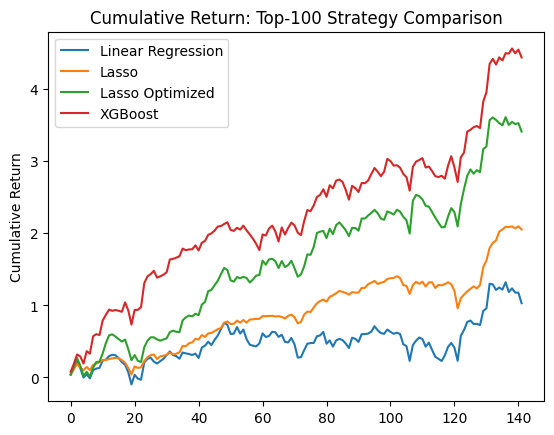

In [71]:
(lr_returns.cumsum()).plot(label='Linear Regression')
(ls_returns.cumsum()).plot(label='Lasso')
(ls_opt_returns.cumsum()).plot(label='Lasso Optimized')
(xgb_returns.cumsum()).plot(label='XGBoost')
plt.legend()
plt.title("Cumulative Return: Top-100 Strategy Comparison")
plt.ylabel("Cumulative Return")
plt.show()


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [31]:
print(type(X_train_clean), X_train_clean.shape)
print(type(y_train_clean), y_train_clean.shape)


<class 'pandas.core.frame.DataFrame'> (2456616, 103)
<class 'pandas.core.series.Series'> (2456616,)


In [32]:
# Convert clean numpy arrays
X_train_tensor = torch.tensor(X_train_clean.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_clean.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_clean.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_clean.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_clean.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_clean.values, dtype=torch.float32).view(-1, 1)

# Create datasets & loaders
train_data = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
val_data = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=1024)


In [34]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

model = MLP(X_train_tensor.shape[1])


In [ ]:
from sklearn.metrics import r2_score

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(20):
    model.train()
    for X_batch, y_batch in train_data:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_r2 = r2_score(y_val_tensor.numpy(), val_preds.numpy())
    print(f"Epoch {epoch+1} - Val R2: {val_r2:.4f}")


Epoch 1 - Val R2: -0.5041
Epoch 2 - Val R2: -0.5171
Epoch 3 - Val R2: -0.4108
Epoch 4 - Val R2: -0.7353
Epoch 5 - Val R2: -0.4040
Epoch 6 - Val R2: -0.4309
Epoch 7 - Val R2: -0.5231
Epoch 8 - Val R2: -0.2782
Epoch 9 - Val R2: -0.3632
Epoch 10 - Val R2: -0.3648
Epoch 11 - Val R2: -0.4045
Epoch 12 - Val R2: -0.4159
Epoch 13 - Val R2: -0.5649
Epoch 14 - Val R2: -0.4451
Epoch 15 - Val R2: -0.3838
Epoch 16 - Val R2: -0.4836
Epoch 17 - Val R2: -0.2872
Epoch 18 - Val R2: -0.3382
Epoch 19 - Val R2: -0.3784
Epoch 20 - Val R2: -0.2218


In [37]:
from sklearn.metrics import mean_squared_error

In [38]:
with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_r2 = r2_score(y_val_tensor.numpy(), val_preds.numpy())
print("Validation R2:", val_r2)
with torch.no_grad():
        test_preds = model(X_test_tensor)
        test_r2 = r2_score(y_test_tensor.numpy(), test_preds.numpy()) 
        test_mse = mean_squared_error(y_test_tensor.numpy(), test_preds.numpy())      
print("Test R2:", test_r2)
print("Test MSE:", test_mse)

Validation R2: -0.2217937707901001
Test R2: -0.14277029037475586
Test MSE: 0.0317356139421463


In [39]:
with torch.no_grad():
    test_preds = model(X_test_tensor).numpy().flatten()

# Align dataframe
test_df_clean = test_df.loc[X_test_clean.index].copy()
test_df_clean['NN_pred'] = test_preds

# Portfolio evaluation
nn_returns = compute_portfolio_returns(test_df_clean, 'NN_pred')
nn_stats = evaluate_portfolio(nn_returns)

print("📊 Neural Network Portfolio")
print(f"Avg Return: {nn_stats[0]:.4f} | Volatility: {nn_stats[1]:.4f} | Sharpe: {nn_stats[2]:.4f}")


📊 Neural Network Portfolio
Avg Return: 0.0356 | Volatility: 0.1122 | Sharpe: 0.3170


📊 Neural Network Portfolio
Avg Return: 0.0281 | Volatility: 0.1151 | Sharpe: 0.2444

In [68]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, TensorDataset

# def objective(trial):
#     # Suggest hyperparameters
#     hidden1 = trial.suggest_int('hidden1', 32, 256)
#     hidden2 = trial.suggest_int('hidden2', 16, 128)
#     dropout_rate = trial.suggest_float('dropout', 0.1, 0.5)
#     lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

def objective(trial):
    hidden1 = trial.suggest_int('hidden1', 64, 512)           
    hidden2 = trial.suggest_int('hidden2', 32, 256)
    dropout_rate = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 5e-5, 5e-3, log=True)  

    # Define model
    class TunedMLP(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(input_dim, hidden1),
                nn.BatchNorm1d(hidden1),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(hidden1, hidden2),
                nn.BatchNorm1d(hidden2),
                nn.ReLU(),
                nn.Linear(hidden2, 1)
            )

        def forward(self, x):
            return self.model(x)

    model = TunedMLP(X_train_tensor.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Train
    model.train()
    for epoch in range(10):  # shorter for tuning speed
        for X_batch, y_batch in DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True):
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor).numpy().flatten()
        score = r2_score(y_val_tensor.numpy(), val_preds)

    return score


In [70]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)

[I 2025-04-25 09:51:04,647] A new study created in memory with name: no-name-51e17890-2081-40af-b684-1b51bc7054d7
[I 2025-04-25 09:55:23,921] Trial 0 finished with value: -0.3643304109573364 and parameters: {'hidden1': 257, 'hidden2': 164, 'dropout': 0.41888511924865335, 'lr': 0.002024380543594693}. Best is trial 0 with value: -0.3643304109573364.
[I 2025-04-25 09:58:20,233] Trial 1 finished with value: -0.19266891479492188 and parameters: {'hidden1': 271, 'hidden2': 66, 'dropout': 0.4255320763517989, 'lr': 7.234381267898717e-05}. Best is trial 1 with value: -0.19266891479492188.
[I 2025-04-25 10:01:50,823] Trial 2 finished with value: -0.6775281429290771 and parameters: {'hidden1': 446, 'hidden2': 87, 'dropout': 0.29969312336869786, 'lr': 0.0014194346127093926}. Best is trial 1 with value: -0.19266891479492188.
[I 2025-04-25 10:25:10,406] Trial 3 finished with value: -0.3283553123474121 and parameters: {'hidden1': 392, 'hidden2': 241, 'dropout': 0.29075690718383446, 'lr': 0.0001542772

Best Parameters: {'hidden1': 325, 'hidden2': 35, 'dropout': 0.48833239245680865, 'lr': 5.053450845809005e-05}


In [69]:
# Trial 1
# Best Parameters: {'hidden1': 42, 'hidden2': 78, 'dropout': 0.4869351111561456, 'lr': 0.0002317325747995254} 

In [71]:
class FinalMLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, dropout):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.model(x)


In [72]:
best_params = study.best_params

final_nn = FinalMLP(
    input_dim=X_train_tensor.shape[1],
    hidden1=best_params['hidden1'],
    hidden2=best_params['hidden2'],
    dropout=best_params['dropout']
)

optimizer = optim.Adam(final_nn.parameters(), lr=best_params['lr'])
loss_fn = nn.MSELoss()

for epoch in range(30):  # Full training
    final_nn.train()
    for X_batch, y_batch in DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True):
        optimizer.zero_grad()
        preds = final_nn(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()

    final_nn.eval()
    with torch.no_grad():
        val_preds = final_nn(X_val_tensor)
        val_r2 = r2_score(y_val_tensor.numpy(), val_preds.numpy())
    print(f"Epoch {epoch+1} - Val R2: {val_r2:.4f}")



Epoch 1 - Val R2: -0.0274
Epoch 2 - Val R2: 0.0020
Epoch 3 - Val R2: 0.0082
Epoch 4 - Val R2: 0.0020
Epoch 5 - Val R2: -0.0042
Epoch 6 - Val R2: -0.0217
Epoch 7 - Val R2: -0.0375
Epoch 8 - Val R2: -0.0539
Epoch 9 - Val R2: -0.0896
Epoch 10 - Val R2: -0.1023
Epoch 11 - Val R2: -0.1276
Epoch 12 - Val R2: -0.1438
Epoch 13 - Val R2: -0.1725
Epoch 14 - Val R2: -0.1941
Epoch 15 - Val R2: -0.1860
Epoch 16 - Val R2: -0.2082
Epoch 17 - Val R2: -0.2113
Epoch 18 - Val R2: -0.2242
Epoch 19 - Val R2: -0.2437
Epoch 20 - Val R2: -0.2569
Epoch 21 - Val R2: -0.2934
Epoch 22 - Val R2: -0.3087
Epoch 23 - Val R2: -0.2952
Epoch 24 - Val R2: -0.2798
Epoch 25 - Val R2: -0.2786
Epoch 26 - Val R2: -0.3265
Epoch 27 - Val R2: -0.2781
Epoch 28 - Val R2: -0.3117
Epoch 29 - Val R2: -0.3354
Epoch 30 - Val R2: -0.3497


In [73]:
with torch.no_grad():
        val_preds = final_nn(X_val_tensor)
        val_r2 = r2_score(y_val_tensor.numpy(), val_preds.numpy())
print("Validation R2:", val_r2)
with torch.no_grad():
        test_preds = final_nn(X_test_tensor)
        test_r2 = r2_score(y_test_tensor.numpy(), test_preds.numpy()) 
        test_mse = mean_squared_error(y_test_tensor.numpy(), test_preds.numpy())      
print("Test R2:", test_r2)
print("Test MSE:", test_mse)

Validation R2: -0.34968578815460205
Test R2: -0.18737423419952393
Test MSE: 0.03297429904341698


In [74]:
with torch.no_grad():
    test_preds = final_nn(X_test_tensor).numpy().flatten()

# Align dataframe
test_df_clean = test_df.loc[X_test_clean.index].copy()
test_df_clean['NN_pred'] = test_preds

# Portfolio evaluation
nn_returns = compute_portfolio_returns(test_df_clean, 'NN_pred')
nn_stats = evaluate_portfolio(nn_returns)

print("📊 Neural Network Portfolio")
print(f"Avg Return: {nn_stats[0]:.4f} | Volatility: {nn_stats[1]:.4f} | Sharpe: {nn_stats[2]:.4f}")


📊 Neural Network Portfolio
Avg Return: 0.0321 | Volatility: 0.1153 | Sharpe: 0.2782


/var/folders/mn/p97zg4190kl_grdrb5c91h7m0000gn/T/ipykernel_25861/3218239944.py:8: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/simratkaurrandhawa/Desktop/SEM_2/FA-590/Project/fa590_pr_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


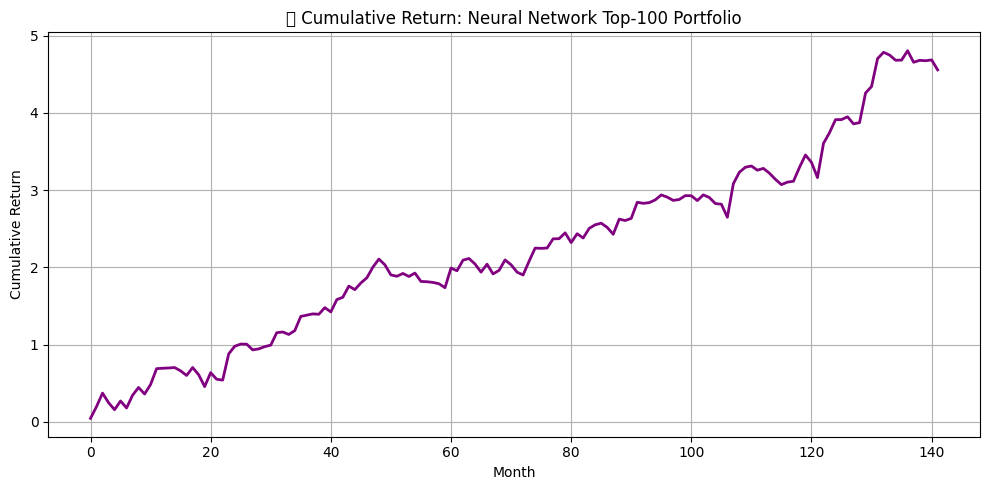

In [75]:
import matplotlib.pyplot as plt

nn_returns.cumsum().plot(figsize=(10, 5), color='purple', linewidth=2)
plt.title("🧠 Cumulative Return: Neural Network Top-100 Portfolio")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()


![alt text](image-1.png)

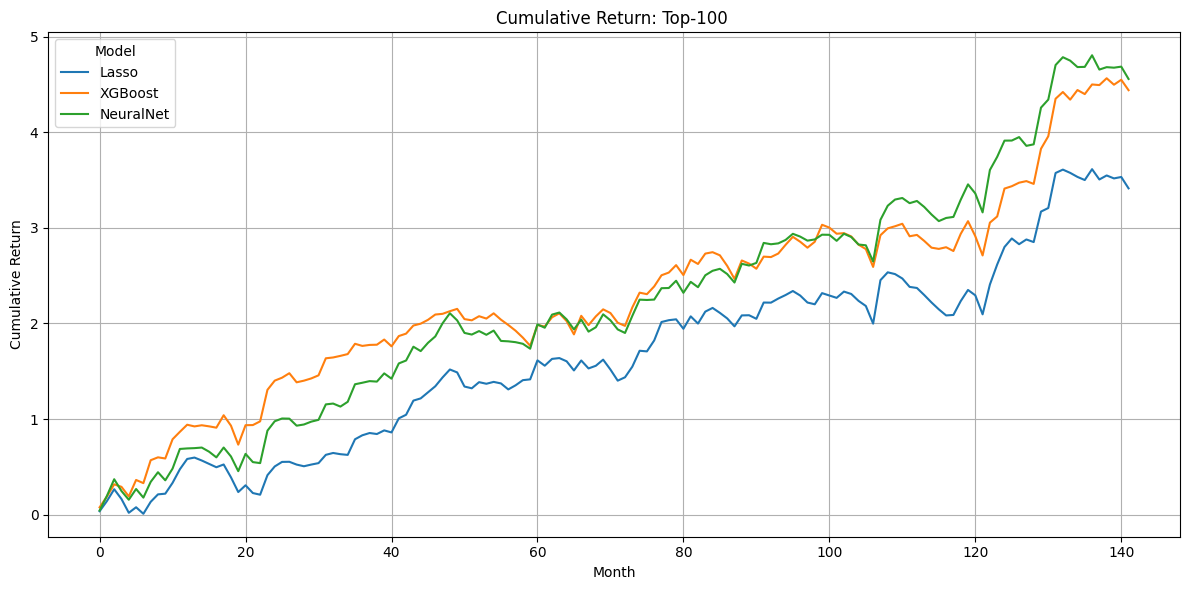

In [78]:
import matplotlib.pyplot as plt

# Make sure all returns are aligned by month
returns_df = pd.DataFrame({
    'Lasso': ls_opt_returns.values[:len(xgb_returns)],
    'XGBoost': xgb_returns.values,
    'NeuralNet': nn_returns.values[:len(xgb_returns)]  # align in case of length mismatch
}, index=xgb_returns.index)  # use XGBoost’s index as base

# Plot cumulative returns
returns_df.cumsum().plot(figsize=(12, 6))
plt.title("Cumulative Return: Top-100 ")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()


# Neural Network Without Hyperparameter Tuning 
![alt text](image.png)

In [67]:
feature_groups = {
    'valuation': ['bm', 'ep', 'dy', 'sp', 'agr'],
    'momentum': ['mom1m', 'mom6m', 'mom12m', 'mom36m'],
    'profitability': ['roeq', 'cfp', 'gma'],  # ⛔ removed 'ebitda' and 'profit'
    'liquidity': ['ill', 'baspread', 'turn', 'retvol'],
    'macro': [col for col in df.columns if col.startswith('macro_')]
}


In [68]:
group_models = {}
group_preds = {}

for group, features in feature_groups.items():
    # Train set
    Xg_train = X_train_clean[features]
    y_train_subset = y_train_clean.copy()
    mask_train = Xg_train.notnull().all(axis=1) & y_train_subset.notnull()
    Xg_train = Xg_train[mask_train]
    yg_train = y_train_subset[mask_train]

    # Validation set
    Xg_val = X_val_clean[features]
    y_val_subset = y_val_clean.copy()
    mask_val = Xg_val.notnull().all(axis=1) & y_val_subset.notnull()
    Xg_val = Xg_val[mask_val]
    yg_val = y_val_subset[mask_val]

    # Train XGBoost
    dtrain = xgb.DMatrix(Xg_train, label=yg_train)
    dval = xgb.DMatrix(Xg_val, label=yg_val)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'max_depth': 5,
        'eta': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    }

    model = xgb.train(params, dtrain, num_boost_round=200, evals=[(dval, 'val')], verbose_eval=50)
    group_models[group] = model

    # Predict on test set
    Xg_test = X_test_clean[features].dropna()
    dtest = xgb.DMatrix(Xg_test)
    test_preds = model.predict(dtest)
    group_preds[group] = pd.Series(test_preds, index=Xg_test.index)


[0]	val-rmse:0.18832
[50]	val-rmse:0.18815
[100]	val-rmse:0.18820
[150]	val-rmse:0.18826
[199]	val-rmse:0.18830
[0]	val-rmse:0.18829
[50]	val-rmse:0.18921
[100]	val-rmse:0.19007
[150]	val-rmse:0.19035
[199]	val-rmse:0.19084
[0]	val-rmse:0.18834
[50]	val-rmse:0.18856
[100]	val-rmse:0.18875
[150]	val-rmse:0.18886
[199]	val-rmse:0.18892
[0]	val-rmse:0.18834
[50]	val-rmse:0.18873
[100]	val-rmse:0.18906
[150]	val-rmse:0.18928
[199]	val-rmse:0.18945
[0]	val-rmse:0.18841
[50]	val-rmse:0.19236
[100]	val-rmse:0.19512
[150]	val-rmse:0.19610
[199]	val-rmse:0.19614


In [69]:
# Combine predictions across common index
ensemble_preds = pd.concat(group_preds.values(), axis=1).mean(axis=1)
test_df_clean.loc[ensemble_preds.index, 'Ensemble_pred'] = ensemble_preds

In [70]:
ensemble_returns = compute_portfolio_returns(test_df_clean, 'Ensemble_pred')
ensemble_stats = evaluate_portfolio(ensemble_returns)

print("📊 Ensemble Portfolio")
print(f"Avg Return: {ensemble_stats[0]:.4f} | Volatility: {ensemble_stats[1]:.4f} | Sharpe: {ensemble_stats[2]:.4f}")


📊 Ensemble Portfolio
Avg Return: 0.0180 | Volatility: 0.1199 | Sharpe: 0.1501


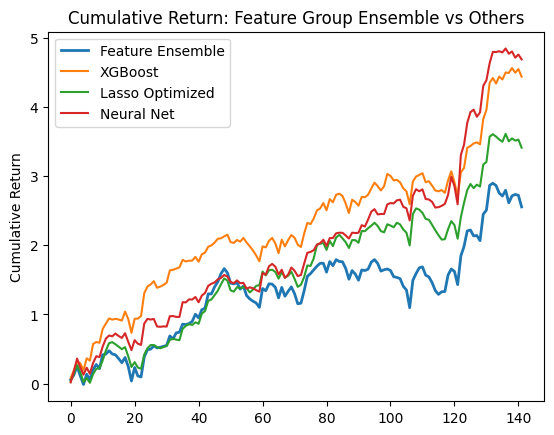

In [71]:
(ensemble_returns.cumsum()).plot(label='Feature Ensemble', linewidth=2)
(xgb_returns.cumsum()).plot(label='XGBoost')
(ls_opt_returns.cumsum()).plot(label='Lasso Optimized')
(nn_returns.cumsum()).plot(label='Neural Net')
plt.title("Cumulative Return: Feature Group Ensemble vs Others")
plt.legend()
plt.ylabel("Cumulative Return")
plt.show()

In [72]:
# Combine group predictions into a DataFrame (only rows with all group predictions)
meta_X = pd.concat(group_preds.values(), axis=1).dropna()
meta_X.columns = list(group_preds.keys())

# Align target (true returns) for meta-model
meta_y = y_test_clean.loc[meta_X.index]


In [73]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

meta_model = Ridge()
meta_model.fit(meta_X, meta_y)

meta_preds = meta_model.predict(meta_X)


In [74]:
stacked_r2 = r2_score(meta_y, meta_preds)
stacked_mse = mean_squared_error(meta_y, meta_preds)

print(f"Stacked Model R²: {stacked_r2:.4f}")
print(f"Stacked Model MSE: {stacked_mse:.6f}")


Stacked Model R²: 0.0065
Stacked Model MSE: 0.027591


In [75]:
test_df_clean.loc[meta_X.index, 'Stacked_pred'] = meta_preds

stacked_returns = compute_portfolio_returns(test_df_clean, 'Stacked_pred')
stacked_stats = evaluate_portfolio(stacked_returns)

print("📊 Stacked Ensemble Portfolio")
print(f"Avg Return: {stacked_stats[0]:.4f} | Volatility: {stacked_stats[1]:.4f} | Sharpe: {stacked_stats[2]:.4f}")


📊 Stacked Ensemble Portfolio
Avg Return: 0.0142 | Volatility: 0.1312 | Sharpe: 0.1081


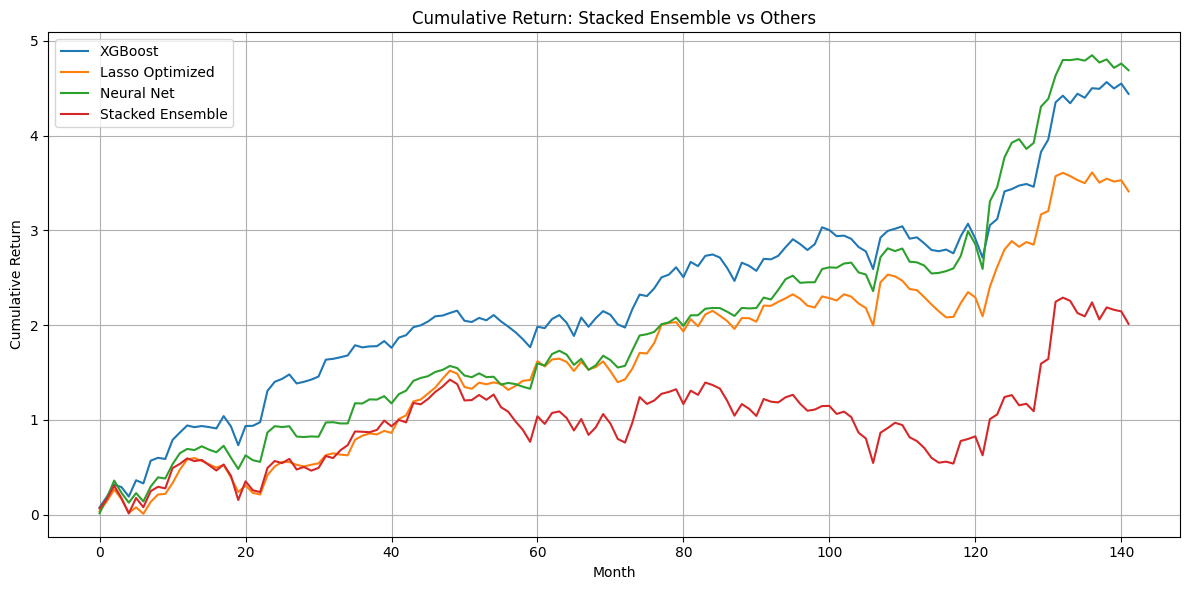

In [76]:
returns_df = pd.DataFrame({
    'XGBoost': xgb_returns.values,
    'Lasso Optimized': ls_opt_returns.values,
    'Neural Net': nn_returns.values,
    'Stacked Ensemble': stacked_returns.values
}, index=stacked_returns.index)

returns_df.cumsum().plot(figsize=(12, 6))
plt.title("Cumulative Return: Stacked Ensemble vs Others")
plt.xlabel("Month")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [77]:
base_preds_train = final_lasso.predict(X_train_clean)
base_preds_test = final_lasso.predict(X_test_clean)

In [78]:
residuals_train = y_train_clean - base_preds_train

In [79]:
residuals_tensor = torch.tensor(residuals_train.values, dtype=torch.float32).view(-1, 1)

In [80]:
residual_model = MLP(X_train_tensor.shape[1])  # Same architecture as before

optimizer = torch.optim.Adam(residual_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(20):
    residual_model.train()
    for X_batch, y_batch in DataLoader(TensorDataset(X_train_tensor, residuals_tensor), batch_size=1024, shuffle=True):
        optimizer.zero_grad()
        preds = residual_model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()


In [81]:
residual_model.eval()
with torch.no_grad():
    residual_preds_test = residual_model(X_test_tensor).numpy().flatten()

final_hybrid_preds = base_preds_test + residual_preds_test


In [82]:
test_df_clean['Hybrid_pred'] = final_hybrid_preds
hybrid_returns = compute_portfolio_returns(test_df_clean, 'Hybrid_pred')
hybrid_stats = evaluate_portfolio(hybrid_returns)

print("📊 Hybrid Model (Lasso + NN) Portfolio")
print(f"Avg Return: {hybrid_stats[0]:.4f} | Volatility: {hybrid_stats[1]:.4f} | Sharpe: {hybrid_stats[2]:.4f}")


📊 Hybrid Model (Lasso + NN) Portfolio
Avg Return: 0.0269 | Volatility: 0.1146 | Sharpe: 0.2344


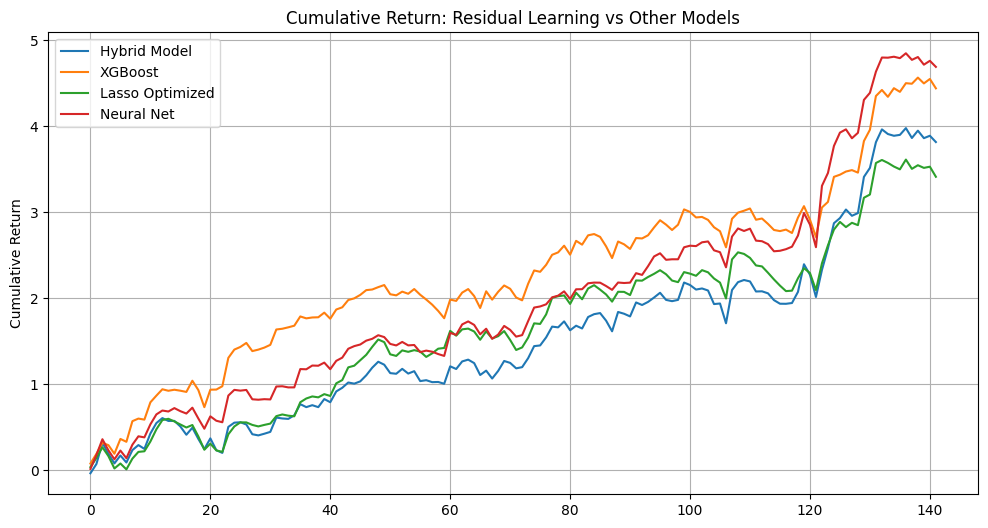

In [83]:
pd.DataFrame({
    'Hybrid Model': hybrid_returns.values,
    'XGBoost': xgb_returns.values,
    'Lasso Optimized': ls_opt_returns.values,
    'Neural Net': nn_returns.values
}).cumsum().plot(figsize=(12, 6))

plt.title("Cumulative Return: Residual Learning vs Other Models")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()


In [87]:
base_preds_train = final_model.predict(dtrain)
base_preds_test = final_model.predict(dtest)


In [88]:
residuals_train = y_train_clean - base_preds_train
residuals_tensor = torch.tensor(residuals_train.values, dtype=torch.float32).view(-1, 1)

In [89]:
residual_model = MLP(X_train_tensor.shape[1])
optimizer = torch.optim.Adam(residual_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(20):
    residual_model.train()
    for X_batch, y_batch in DataLoader(TensorDataset(X_train_tensor, residuals_tensor), batch_size=1024, shuffle=True):
        optimizer.zero_grad()
        preds = residual_model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()


In [90]:
residual_model.eval()
with torch.no_grad():
    residual_preds_test = residual_model(X_test_tensor).numpy().flatten()

final_hybrid_preds_xgb = base_preds_test + residual_preds_test


In [91]:
test_df_clean['Hybrid_XGB_pred'] = final_hybrid_preds_xgb
hybrid_xgb_returns = compute_portfolio_returns(test_df_clean, 'Hybrid_XGB_pred')
hybrid_xgb_stats = evaluate_portfolio(hybrid_xgb_returns)

print("📊 Hybrid Model (XGBoost + NN) Portfolio")
print(f"Avg Return: {hybrid_xgb_stats[0]:.4f} | Volatility: {hybrid_xgb_stats[1]:.4f} | Sharpe: {hybrid_xgb_stats[2]:.4f}")


📊 Hybrid Model (XGBoost + NN) Portfolio
Avg Return: 0.0240 | Volatility: 0.1216 | Sharpe: 0.1973


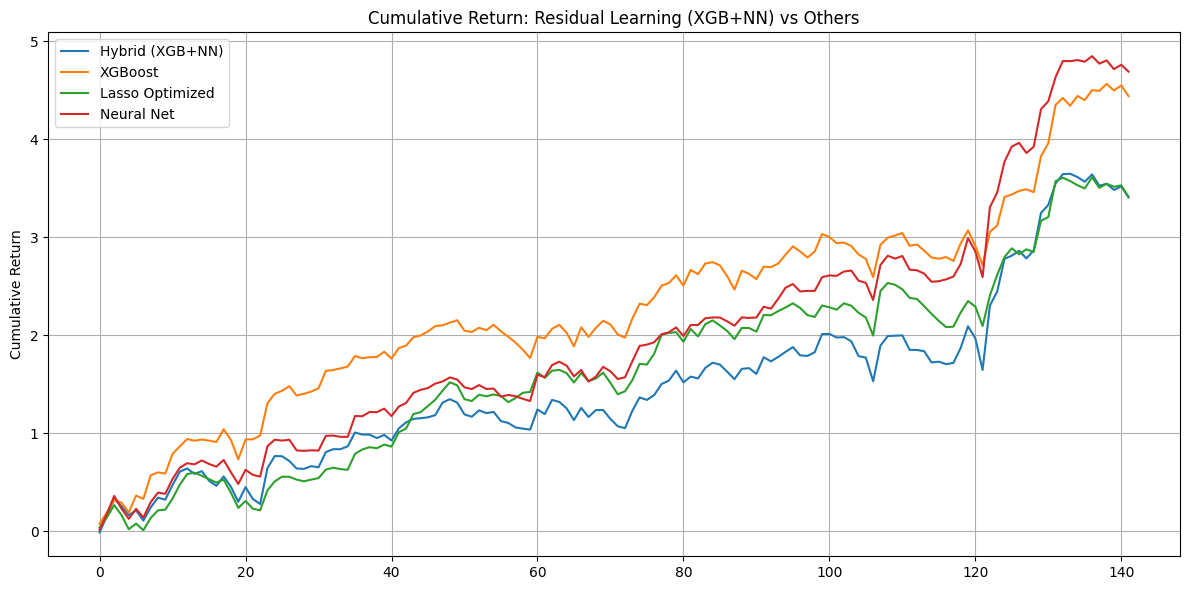

: 

In [92]:
pd.DataFrame({
    'Hybrid (XGB+NN)': hybrid_xgb_returns.values,
    'XGBoost': xgb_returns.values,
    'Lasso Optimized': ls_opt_returns.values,
    'Neural Net': nn_returns.values
}).cumsum().plot(figsize=(12, 6))

plt.title("Cumulative Return: Residual Learning (XGB+NN) vs Others")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
model.eval()
with torch.no_grad():
    nn_preds_train = model(X_train_tensor).numpy().flatten()
    nn_preds_test = model(X_test_tensor).numpy().flatten()


In [39]:
residuals_train_rev = y_train_clean - nn_preds_train

In [41]:
import xgboost as xgb

In [42]:
dtrain_rev = xgb.DMatrix(X_train_clean, label=residuals_train_rev)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

residual_xgb = xgb.train(params, dtrain_rev, num_boost_round=200)


In [43]:
dtest = xgb.DMatrix(X_test_clean)
residual_xgb_preds = residual_xgb.predict(dtest)

final_reverse_hybrid_preds = nn_preds_test + residual_xgb_preds

In [44]:
test_df_clean['Reverse_Hybrid_pred'] = final_reverse_hybrid_preds
reverse_hybrid_returns = compute_portfolio_returns(test_df_clean, 'Reverse_Hybrid_pred')
reverse_hybrid_stats = evaluate_portfolio(reverse_hybrid_returns)

print("📊 Reverse Hybrid (NN + XGB) Portfolio")
print(f"Avg Return: {reverse_hybrid_stats[0]:.4f} | Volatility: {reverse_hybrid_stats[1]:.4f} | Sharpe: {reverse_hybrid_stats[2]:.4f}")


📊 Reverse Hybrid (NN + XGB) Portfolio
Avg Return: 0.0302 | Volatility: 0.1149 | Sharpe: 0.2630


In [45]:
print("Validation R2:", r2_score(y_val_clean, residual_xgb.predict(dval)))
print("Test R2:", r2_score(y_test_clean, residual_xgb.predict(dtest)))
print("Test MSE:", mean_squared_error(y_test_clean, residual_xgb.predict(dtest)))

NameError: name 'dval' is not defined